<a href="https://colab.research.google.com/github/mariaandraddz/ciclo-formativo-Pretalab/blob/main/PROJETO_FINAL_MARIA_EDUARDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise Exploratória de Músicas do Spotify
---
**Objetivo**
O objetivo desta análise é comparar os gêneros musicais samba e black metal, investigando suas principais características, como popularidade, duração e atributos musicais (dançabilidade, energia, entre outros). Busca-se identificar padrões, diferenças e possíveis relações entre esses gêneros, utilizando técnicas de análise exploratória de dados e visualizações gráficas.



Dataset: `spotify_dataset.csv`

Arquivo disponível neste link: https://drive.google.com/file/d/1G1TKSidyKCrPfLMike1ECPRG4JiBEvEr/view?usp=sharing

In [136]:
pip install --upgrade pandas

In [137]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [138]:
df = pd.read_csv("spotify_dataset.csv", index_col=0, sep=',', on_bad_lines='warn')

# **1. Inspeção Básica**

In [139]:
#Visualização das 5 primeiras linhas
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [140]:
#Visualizar informações do dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

É possível identificar que há valores ausentes

In [141]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [142]:
#Os gêneros musicais presentes no dataset
df['track_genre'].unique()

<ArrowStringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str

Foi possível identificar esses gêneros musicais presentes no dataset

# **2. LImpeza e preparação de dados**

Para começar a análise criarei um novo dataframe com os gêneros musicais que pretendo focar minha análise

In [143]:
#criando um novo dataframe com foco em samba e black_metal
df_foco = df[df['track_genre'].isin(['samba', 'black-metal'])]

In [144]:
#Padronização de track_genre para minusculas
df_foco['track_genre'] = df_foco['track_genre'].str.lower()

In [145]:
#Verificação da existência de duplicatas
df_foco.duplicated().sum()

np.int64(3)

In [146]:
#Removendo as duplicatas
df_foco = df_foco.drop_duplicates()

In [147]:
#Quais são essas linhas duplicadas?
df_foco[df_foco.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,


In [148]:
#Verificando se foram realmente removidas
df_foco[df_foco.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,


In [149]:
df_foco.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
6000,0mJUxFpEI1eAOIIfnNoZ4G,Cradle Of Filth,Lovecraft & Witch Hearts,Hallowed Be Thy Name,51,430733,False,0.428,0.972,2,-1.998,0,0.0666,0.000072,0.0736,0.0787,0.2250,118.306,4,black-metal
6001,7v9HNMlAe2UBaEhvaCk5wX,Make Them Suffer,Doomswitch,Doomswitch,58,275205,True,0.250,0.952,9,-4.059,0,0.2090,0.000024,0.0135,0.0892,0.1260,143.022,3,black-metal
6002,3wBHF6evf55iEzyMtReJSH,Behemoth,I Loved You at Your Darkest,Bartzabel,47,301285,False,0.468,0.913,6,-5.670,1,0.0720,0.026500,0.0769,0.0787,0.1870,109.003,4,black-metal
6003,5FBToB2y0ie4fq3WjfsFFE,Sadness,I Want to Be There,I Want to Be with You,41,355474,False,0.144,0.466,5,-6.715,1,0.0522,0.686000,0.4230,0.0764,0.0737,87.290,4,black-metal
6004,6WuqJLVZcyJklg7lIozAO8,Cradle Of Filth,Nymphetamine Special Edition,Nymphetamine Fix,54,302360,False,0.462,0.905,0,-3.825,0,0.0438,0.000660,0.0402,0.0839,0.2530,122.925,3,black-metal


In [150]:
df_foco.info()

<class 'pandas.DataFrame'>
Index: 1997 entries, 6000 to 96999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          1997 non-null   str    
 1   artists           1997 non-null   str    
 2   album_name        1997 non-null   str    
 3   track_name        1997 non-null   str    
 4   popularity        1997 non-null   int64  
 5   duration_ms       1997 non-null   int64  
 6   explicit          1997 non-null   bool   
 7   danceability      1997 non-null   float64
 8   energy            1997 non-null   float64
 9   key               1997 non-null   int64  
 10  loudness          1997 non-null   float64
 11  mode              1997 non-null   int64  
 12  speechiness       1997 non-null   float64
 13  acousticness      1997 non-null   float64
 14  instrumentalness  1997 non-null   float64
 15  liveness          1997 non-null   float64
 16  valence           1997 non-null   float64
 17  tempo  

In [151]:
df_foco['track_genre'].unique()

<ArrowStringArray>
['black-metal', 'samba']
Length: 2, dtype: str

In [152]:
#Verificando se há valores ausentes
df_foco.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

A partir do recorte em dois gêneros, nenhum dos dois tem valores ausentes

In [153]:
#Visualização da nova coluna
df_foco.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
6000,0mJUxFpEI1eAOIIfnNoZ4G,Cradle Of Filth,Lovecraft & Witch Hearts,Hallowed Be Thy Name,51,430733,False,0.428,0.972,2,-1.998,0,0.0666,0.000072,0.0736,0.0787,0.2250,118.306,4,black-metal
6001,7v9HNMlAe2UBaEhvaCk5wX,Make Them Suffer,Doomswitch,Doomswitch,58,275205,True,0.250,0.952,9,-4.059,0,0.2090,0.000024,0.0135,0.0892,0.1260,143.022,3,black-metal
6002,3wBHF6evf55iEzyMtReJSH,Behemoth,I Loved You at Your Darkest,Bartzabel,47,301285,False,0.468,0.913,6,-5.670,1,0.0720,0.026500,0.0769,0.0787,0.1870,109.003,4,black-metal
6003,5FBToB2y0ie4fq3WjfsFFE,Sadness,I Want to Be There,I Want to Be with You,41,355474,False,0.144,0.466,5,-6.715,1,0.0522,0.686000,0.4230,0.0764,0.0737,87.290,4,black-metal
6004,6WuqJLVZcyJklg7lIozAO8,Cradle Of Filth,Nymphetamine Special Edition,Nymphetamine Fix,54,302360,False,0.462,0.905,0,-3.825,0,0.0438,0.000660,0.0402,0.0839,0.2530,122.925,3,black-metal


In [154]:
#Nova coluna com a duração em minutos
df_foco['duration_min'] = df_foco['duration_ms'] / 6000

In [155]:
#A duração média de black-metal e samba
duracao_media = df_foco[df_foco['track_genre'].isin(['black-metal', 'samba'])].groupby('track_genre')['duration_min'].mean()

In [156]:
duracao_media

track_genre
black-metal    51.836400
samba          37.750399
Name: duration_min, dtype: float64

# **3. Análise descritiva e Visualização**

In [157]:
df_foco.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,1997.000000,1.997000e+03,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,30.655984,2.686969e+05,0.435992,0.773531,5.290936,-7.510818,0.619930,0.085403,0.258868,0.224349,0.342307,0.443147,123.349378,3.897346,44.782819
std,11.694008,1.249422e+05,0.185330,0.197066,3.546709,2.997618,0.485525,0.064240,0.299345,0.341925,0.274581,0.305981,29.897593,0.422297,20.823707
min,0.000000,3.960000e+04,0.062900,0.026300,0.000000,-23.952000,0.000000,0.023000,0.000000,0.000000,0.018600,0.017700,51.436000,1.000000,6.600000
25%,19.000000,1.972240e+05,0.282000,0.661000,2.000000,-8.900000,0.000000,0.044000,0.000045,0.000000,0.117000,0.151000,98.148000,4.000000,32.870667
50%,36.000000,2.453600e+05,0.452000,0.823000,6.000000,-7.086000,1.000000,0.065100,0.079800,0.000649,0.251000,0.399000,120.033000,4.000000,40.893333
75%,40.000000,3.092130e+05,0.581000,0.941000,9.000000,-5.455000,1.000000,0.103000,0.546000,0.449000,0.490000,0.733000,145.811000,4.000000,51.535500
max,68.000000,1.478618e+06,0.895000,1.000000,11.000000,-1.152000,1.000000,0.705000,0.987000,0.993000,0.988000,0.978000,204.767000,5.000000,246.436333


Foi possível identificar a média: 30.65; mediana: 36.00; desvio padrão: 11.69(popularidade)

O que isso significa?

*   A média mostra que as músicas do dataset tem uma popularidade moderada
*   O desvio mostra que existe uma variação considerável na popularidade; Há músicas bem diferentes entre si (algumas pouco populares, outras mais conhecidas)



Comparação de média e mediana


*   Tem músicas com popularidade muito baixa puxando a média para baixo

A distribuição é assimétrica a esquerda, além de também não ter outliers


1.   O que significa essa distribuição?

*   Tem a presença de músicas com uma popularidade média/alta

*   Algumas músicas tem uma popularidade baixa



A distribuição é assimétrica a esquerda, além de também não ter outliers


1.   O que significa essa distribuição?

*   Tem a presença de músicas com uma popularidade média/alta

*   Algumas músicas tem uma popularidade baixa



/tmp/ipykernel_2187/1792333166.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_foco['popularity'], palette='magma')


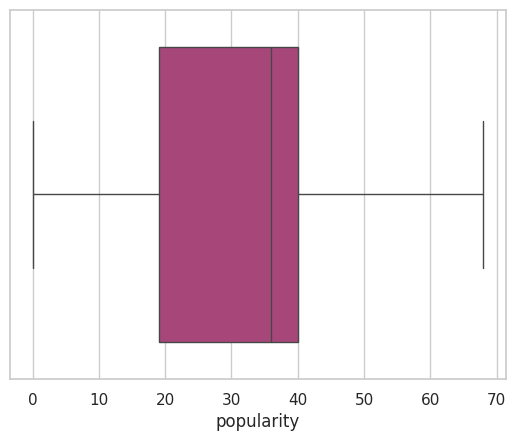

In [158]:
sns.boxplot(x=df_foco['popularity'], palette='magma')
plt.show()



1.  Qual é a duração média das músicas?



/tmp/ipykernel_2187/1298238960.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='track_genre', y='duration_min', data=df_foco, palette='magma')


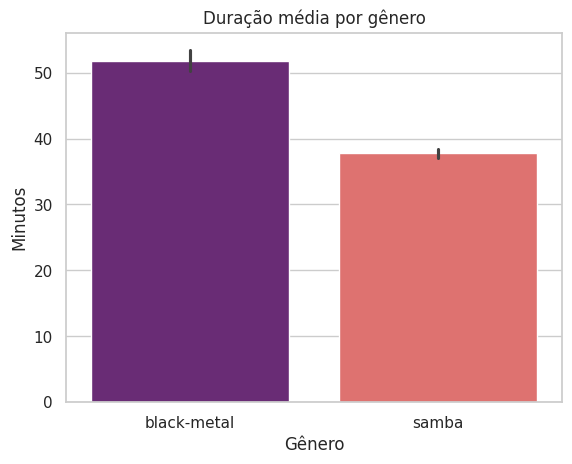

In [160]:
sns.barplot(x='track_genre', y='duration_min', data=df_foco, palette='magma')
plt.title("Duração média por gênero")
plt.xlabel('Gênero')
plt.ylabel('Minutos')
plt.show()

Percebe-se que as músicas que são do gênero Black metal duram mais do que as músicas do gênero samba

/tmp/ipykernel_2187/3673559542.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='track_genre', y='popularity', data=df_foco, palette='magma')


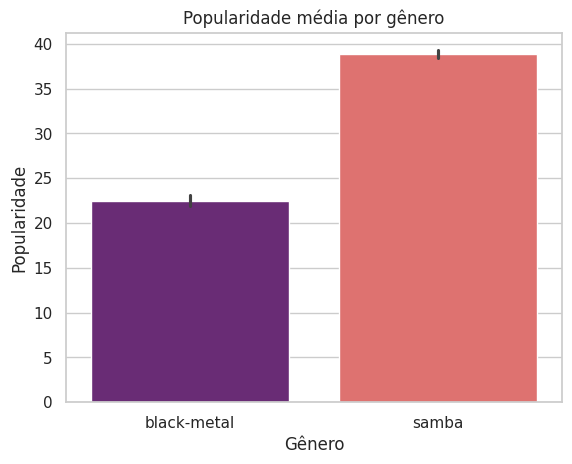

In [161]:
sns.barplot(x='track_genre', y='popularity', data=df_foco, palette='magma')
plt.title('Popularidade média por gênero')
plt.xlabel('Gênero')
plt.ylabel('Popularidade')
plt.show()

/tmp/ipykernel_2187/2381742689.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='track_genre', y='danceability', data=df_foco, palette='magma')


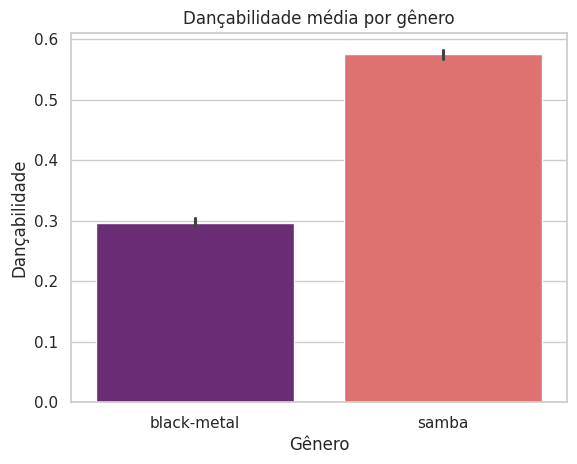

In [162]:
sns.barplot(x='track_genre', y='danceability', data=df_foco, palette='magma')
plt.title('Dançabilidade média por gênero')
plt.xlabel('Gênero')
plt.ylabel('Dançabilidade')
plt.show()

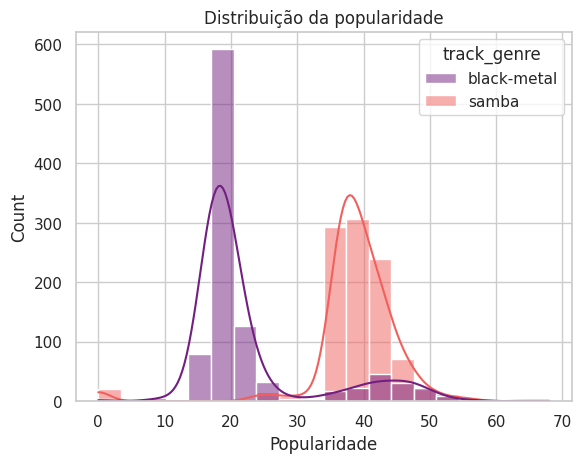

In [163]:
sns.histplot(data=df_foco, x='popularity', hue='track_genre', kde=True, bins=20, palette='magma')
plt.title('Distribuição da popularidade')
plt.xlabel('Popularidade')
plt.ylabel('Count')

plt.show()

* Popularidade do Samba: As músicas
de samba tendem a ter uma distribuição de popularidade mais concentrada em valores médios a altos. A curva para o samba provavelmente mostra um pico em um valor de popularidade mais elevado, indicando que a maioria das músicas de samba neste conjunto de dados tem uma popularidade considerável.

* Popularidade do Black Metal: As músicas de black metal, por outro lado, parecem ter uma distribuição de popularidade mais concentrada em valores mais baixos. A curva KDE para o black metal deve apresentar um pico em um valor de popularidade menor, sugerindo que, em geral, as músicas deste gênero são menos populares neste dataset.

* Comparação: Há uma clara distinção entre os dois gêneros. O samba geralmente apresenta músicas mais populares do que o black metal, como indicado pela posição de seus picos e pela dispersão de suas distribuições no eixo da popularidade.

/tmp/ipykernel_2187/4255750186.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='track_genre', y='popularity', data=df_foco, palette='magma')


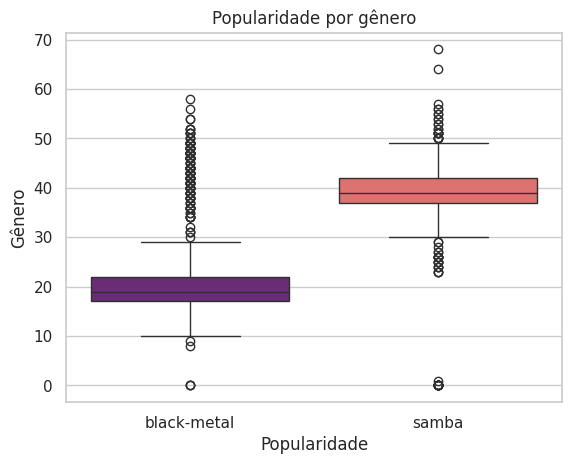

In [164]:
sns.boxplot(x='track_genre', y='popularity', data=df_foco, palette='magma')
plt.title('Popularidade por gênero')
plt.xlabel('Popularidade')
plt.ylabel('Gênero')
plt.show()

* Samba: Isso sugere que as músicas de samba, em geral, têm uma popularidade mediana mais elevada e uma maior concentração de músicas com popularidade moderada a alta. Qualquer outlier indica que as músicas de samba excepcionalmente populares ou impopulares.

* Black Metal: Para o black metal, o boxplot deve estar em uma faixa de popularidade mais baixa. A mediana e a maior parte dos dados (representados pela caixa) estarão em valores menores, indicando que este gênero, em média, é menos popular no dataset. Assim como no samba, outliers poderiam mostrar músicas de black metal com popularidade atípica.

* Comparação: A diferença clara entre os dois boxplots (com o do samba geralmente mais acima no eixo de popularidade) reforça a conclusão do histograma: o samba tende a ter músicas mais populares do que o black metal neste conjunto de dados, com a maioria das músicas de samba se concentrando em faixas de popularidade mais altas.


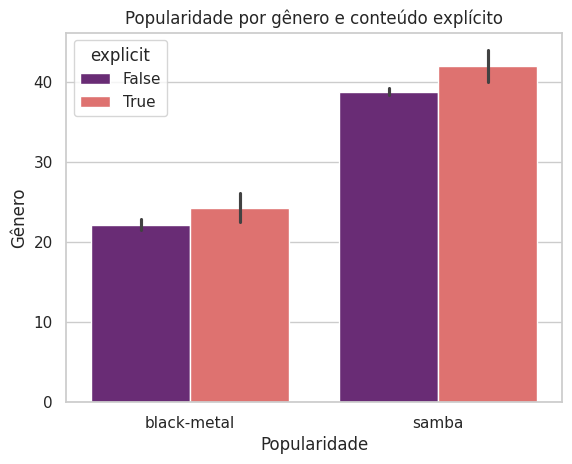

In [165]:
sns.barplot(x='track_genre', y='popularity', hue='explicit', data=df_foco, palette='magma')
plt.title('Popularidade por gênero e conteúdo explícito')
plt.xlabel('Popularidade')
plt.ylabel('Gênero')
plt.show()

* Popularidade Geral por Gênero: Podemos reiterar que, em média, as músicas de samba mostram uma popularidade mais alta do que as de black metal.

* Conteúdo Explícito no Samba: Observa-se como a presença ou ausência de conteúdo explícito impacta a popularidade dentro do gênero samba.

* Conteúdo Explícito no Black Metal: Similarmente, para o black metal, o gráfico revelará se as músicas explícitas ou não explícitas tendem a ser mais populares

* Comparação entre Gêneros e Conteúdo Explícito: O gráfico permite uma comparação cruzada. Por exemplo, podemos ver se músicas não explícitas de samba são mais populares que músicas explícitas de black metal, ou vice-versa. Isso ajuda a entender se o gênero ou a presença de conteúdo explícito é o fator dominante na popularidade de uma faixa.

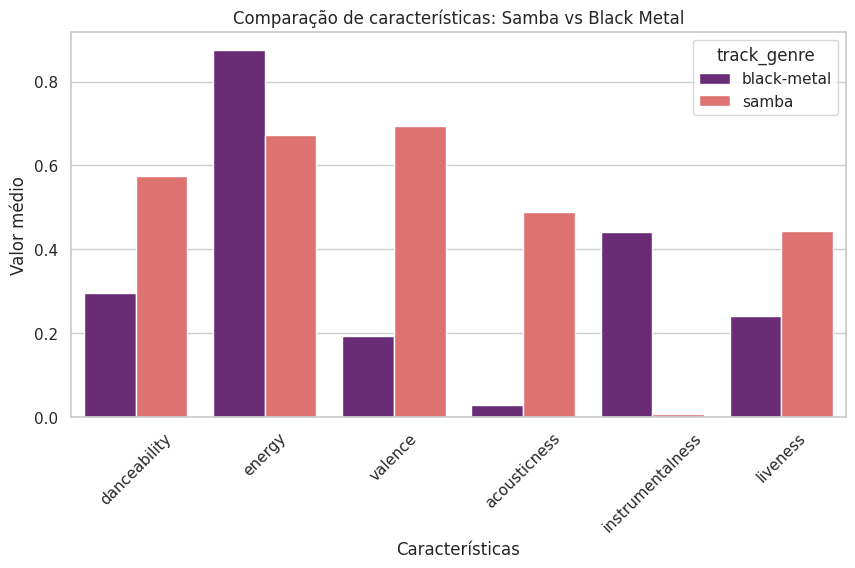

In [166]:
cols = ['danceability', 'energy', 'valence',
        'acousticness', 'instrumentalness', 'liveness']

df_mean = df_foco.groupby('track_genre')[cols].mean().reset_index()

df_melt = df_mean.melt(id_vars='track_genre',
                       var_name='feature',
                       value_name='value')

plt.figure(figsize=(10,5))
sns.barplot(data=df_melt, x='feature', y='value', hue='track_genre', palette='magma')

plt.title('Comparação de características: Samba vs Black Metal')
plt.xlabel('Características')
plt.ylabel('Valor médio')
plt.xticks(rotation=45)

plt.show()

# Conclusão da Análise

A análise comparativa entre os gêneros samba e black metal evidenciou diferenças significativas em suas características musicais. O samba se destacou principalmente por apresentar maior dançabilidade (danceability) e valência (valence), indicando músicas mais animadas, rítmicas e associadas a emoções positivas. Em contrapartida, o black metal apresentou níveis mais elevados de energia (energy) e, em alguns casos, maior instrumentalidade, refletindo um estilo mais intenso, pesado e menos voltado à dança.

Em relação à duração das músicas, observou-se que o black metal tende a possuir faixas mais longas, enquanto o samba apresenta composições mais curtas e diretas. Quanto à popularidade, a análise mostrou variações entre os gêneros, podendo indicar diferenças no alcance e no público de cada estilo.

De modo geral, os resultados reforçam que os dois gêneros possuem propostas musicais bastante distintas: o samba é mais acessível, dançante e emocionalmente leve, enquanto o black metal é mais complexo, energético e nichado. Essas diferenças ficam evidentes tanto nas estatísticas descritivas quanto nas visualizações gráficas realizadas.